# EDA and Hypothesis Testing – Flight Price Analysis

In this notebook I'm going to look at my merged flight dataset and try to understand
how oil prices and Indian public holidays relate to ticket prices.

My two main questions are:
1. Is there a correlation between WTI oil prices and flight prices?
2. Are flight prices different on holidays vs. normal days?

## 1. Loading the data

In [31]:
# same imports we always use in recitations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [32]:
df = pd.read_csv('master_flight_data.csv')
print('rows, columns:', df.shape)
df.head()

rows, columns: (300261, 14)


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class,oil_price_wti,is_holiday
0,2022-02-11,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,5953,Economy,91.42,False
1,2022-02-11,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,5953,Economy,91.42,False
2,2022-02-11,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,5956,Economy,91.42,False
3,2022-02-11,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,5955,Economy,91.42,False
4,2022-02-11,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,5955,Economy,91.42,False


## 2. Basic stats – what does the data look like?

In [33]:
# numerical summary – same as df.describe() we did in recitations
df.describe()

,num_code,price,oil_price_wti
count,300261.000000,300261.000000,300261.000000
mean,1417.771709,20883.717666,101.323275
std,1974.514439,22695.911266,8.430721
min,101.000000,1105.000000,89.890000
25%,637.000000,4783.000000,92.584607
50%,818.000000,7425.000000,102.990000
75%,927.000000,42521.000000,107.724050
max,9991.000000,123071.000000,119.650000


In [34]:
# text/categorical columns
df.describe(include='object')

,date,airline,ch_code,dep_time,from,time_taken,stop,arr_time,to,class
count,300261,300261,300261,300261,300261,300261,300261,300261,300261,300261
unique,49,8,8,251,6,483,40,266,6,2
top,2022-03-07,Vistara,UK,07:00,Delhi,02h 10m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,19:55,Mumbai,Economy
freq,6633,127859,127859,8760,61345,4242,243603,9194,59109,206774


## 3. Flight price distribution

Let me plot a histogram and a boxplot to get a feeling for the price data.

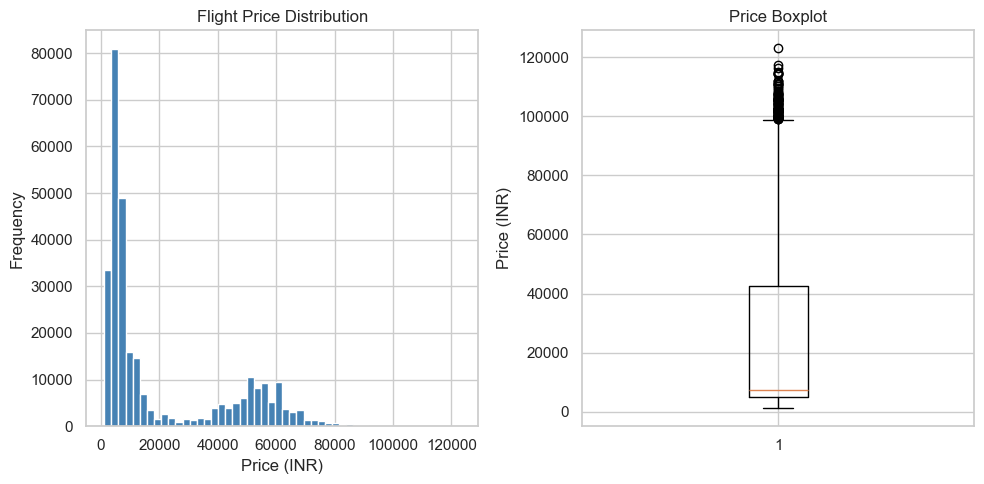

Mean  : 20883.72
Median: 7425.0
Std   : 22695.91


In [35]:
plt.figure(figsize=(10, 5))

# histogram on the left
plt.subplot(1, 2, 1)
plt.hist(df['price'], bins=50, color='steelblue', edgecolor='white')
plt.title('Flight Price Distribution')
plt.xlabel('Price (INR)')
plt.ylabel('Frequency')
plt.grid(True)

# boxplot on the right to see spread and outliers
plt.subplot(1, 2, 2)
plt.boxplot(df['price'])
plt.title('Price Boxplot')
plt.ylabel('Price (INR)')
plt.grid(True)

plt.tight_layout()
plt.show()

# quick summary numbers
print('Mean  :', round(df['price'].mean(), 2))
print('Median:', round(df['price'].median(), 2))
print('Std   :', round(df['price'].std(), 2))

## 4. Oil price vs. flight price – scatter plot

The oil data only covers Feb–Mar 2022 so I need to drop rows where `oil_price_wti` is NaN first.

In [36]:
# keep only rows that have an oil price
oil_df = df.dropna(subset=['oil_price_wti'])
print('rows with oil data:', len(oil_df))

rows with oil data: 300261


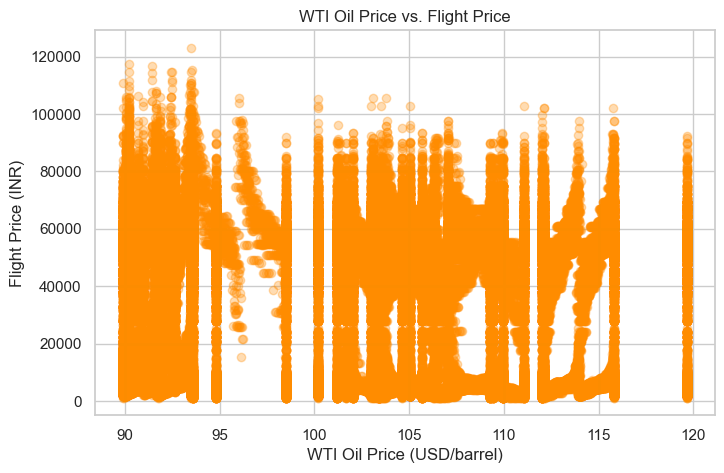

In [37]:
# scatter: oil price on x-axis, flight price on y-axis
plt.figure(figsize=(8, 5))
plt.scatter(oil_df['oil_price_wti'], oil_df['price'], alpha=0.3, color='darkorange')
plt.title('WTI Oil Price vs. Flight Price')
plt.xlabel('WTI Oil Price (USD/barrel)')
plt.ylabel('Flight Price (INR)')
plt.grid(True)
plt.show()

## 5. Correlation between oil price and flight price

I'll calculate Pearson correlation the same manual way shown in Recitation 3,
then double-check it with numpy.

In [38]:
# manual Pearson r – from Recitation 3
x = oil_df['oil_price_wti'].values
y = oil_df['price'].values

mean_x = np.mean(x)
mean_y = np.mean(y)

cov = np.mean((x - mean_x) * (y - mean_y))
std_x = np.std(x)
std_y = np.std(y)

r = cov / (std_x * std_y)

print('Pearson r (manual):', round(r, 4))
print('Pearson r (numpy) :', round(np.corrcoef(x, y)[0, 1], 4))

Pearson r (manual): -0.0719
Pearson r (numpy) : -0.0719


## 6. Hypothesis Test 1 – Is the correlation statistically significant?

H0: r = 0 (no linear relationship between oil price and flight price)  
H1: r ≠ 0  
Significance level: α = 0.05

I'm using `stats.pearsonr` which returns both the correlation and the p-value.

In [39]:
corr, p_val = stats.pearsonr(x, y)

print('Pearson r :', round(corr, 4))
print('p-value   :', p_val)

alpha = 0.05
if p_val < alpha:
    print('\nResult: reject H0 – the correlation is statistically significant.')
else:
    print('\nResult: fail to reject H0 – no significant correlation found.')

Pearson r : -0.0719
p-value   : 0.0

Result: reject H0 – the correlation is statistically significant.


## 7. Holiday vs. non-holiday prices

Now let me compare flight prices on public holidays vs. normal days.

In [40]:
holiday_prices     = df[df['is_holiday'] == 1]['price']
non_holiday_prices = df[df['is_holiday'] == 0]['price']

print('Holiday flights    :', len(holiday_prices))
print('Non-holiday flights:', len(non_holiday_prices))
print()
print('Mean price – holiday    :', round(holiday_prices.mean(), 2))
print('Mean price – non-holiday:', round(non_holiday_prices.mean(), 2))

Holiday flights    : 13032
Non-holiday flights: 287229

Mean price – holiday    : 19506.64
Mean price – non-holiday: 20946.2


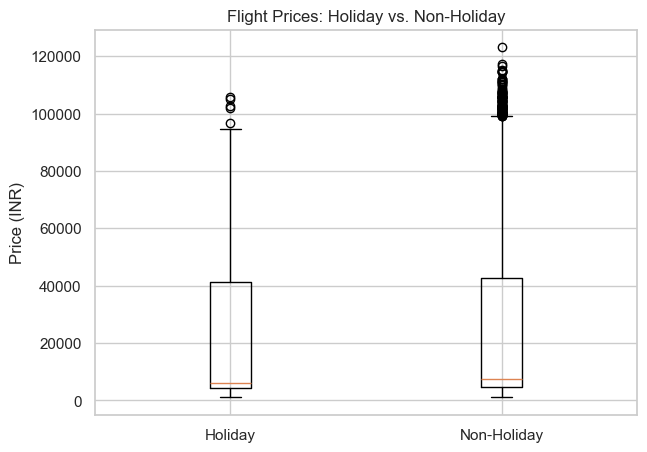

In [41]:
# boxplots side by side to visually compare the two groups
plt.figure(figsize=(7, 5))
plt.boxplot(
    [holiday_prices, non_holiday_prices],
    labels=['Holiday', 'Non-Holiday']
)
plt.title('Flight Prices: Holiday vs. Non-Holiday')
plt.ylabel('Price (INR)')
plt.grid(True)
plt.show()

## 8. Hypothesis Test 2 – Are holiday prices different?

H0: mean price on holidays = mean price on non-holidays  
H1: they are different  
α = 0.05

Using the two-sample t-test from Recitation 5 (`stats.ttest_ind`).
I set `equal_var=False` because the two groups have very different sizes so it's
safer not to assume the variances are equal (Welch's version).

In [42]:
# exact same syntax as Recitation 5
t_stat, p_val = stats.ttest_ind(holiday_prices, non_holiday_prices, equal_var=False)

print('t-statistic:', round(t_stat, 4))
print('p-value    :', p_val)

alpha = 0.05
if p_val < alpha:
    print('\nResult: reject H0 – holiday prices are significantly different from non-holiday prices.')
else:
    print('\nResult: fail to reject H0 – no significant difference found.')

t-statistic: -7.0821
p-value    : 1.4866966649533515e-12

Result: reject H0 – holiday prices are significantly different from non-holiday prices.
